
# Student Performance Analysis and Prediction

## Context

Educational institutions across the country are continuously striving to improve student outcomes and bridge achievement gaps. Understanding the factors that influence academic performance is crucial for educators, administrators, and policymakers to make informed decisions about resource allocation and intervention strategies.

Student academic success is influenced by a complex interplay of demographic, socioeconomic, and educational factors. Factors such as parental education level, access to resources (indicated by lunch program participation), test preparation opportunities, and demographic characteristics all play significant roles in shaping student performance. However, the relative impact of these factors and how they interact with each other is not always clear.

Schools and districts collect vast amounts of data on student demographics and academic performance, but this data often remains underutilized. By analyzing patterns in this data, educational institutions can identify at-risk student populations, understand which interventions are most effective, and allocate resources more strategically to support student success.

This analysis examines performance data from 1,000 students across three core subjects: Mathematics, Reading, and Writing. The data includes demographic information, socioeconomic indicators, and participation in test preparation programs, providing a comprehensive view of factors that may influence academic achievement.

---

## Objectives

The primary goal of this analysis is to understand how various demographic and socioeconomic factors influence student academic performance, and to build predictive models that can help educators identify students who may need additional support.

### Key Questions to Answer:

1. **What is the distribution of student performance across different subjects?**
   - How are math, reading, and writing scores distributed?
   - Are scores normally distributed or skewed?

2. **How do demographic factors affect academic performance?**
   - Does gender influence performance in different subjects?
   - How does race/ethnicity correlate with academic outcomes?

3. **What is the impact of socioeconomic factors on student success?**
   - How does parental education level affect student scores?
   - What is the performance gap between students with standard lunch vs. free/reduced lunch programs?

4. **Does test preparation make a significant difference?**
   - How much do students who complete test preparation programs improve compared to those who don't?
   - Is the impact of test preparation consistent across all subjects?

5. **Are there correlations between different subject performances?**
   - Do students who excel in one subject tend to perform well in others?
   - What are the correlation coefficients between math, reading, and writing scores?

6. **Which factors have the strongest influence on overall academic performance?**
   - What are the most impactful controllable vs. non-controllable factors?
   - Can we quantify the relative importance of each factor?

7. **Can we predict student performance based on their characteristics?**
   - Build a predictive model to forecast student scores
   - Identify students at risk of underperformance for early intervention

### Expected Outcomes:

- Identify the most impactful factors affecting student performance
- Provide data-driven recommendations for educational interventions
- Build a predictive model to forecast student outcomes
- Highlight achievement gaps that require targeted support

---

## Data Description

The dataset contains academic performance records for **1,000 students**, including their demographic information, socioeconomic background, participation in test preparation programs, and scores across three core subjects.

### Dataset Overview:
- **Total Records**: 1,000 students
- **Features**: 8 variables (5 categorical, 3 numerical)
- **Target Variables**: Math Score, Reading Score, Writing Score
- **Data Type**: Cross-sectional student performance data

The data provides a comprehensive view of factors that may influence academic achievement, including both demographic characteristics and educational interventions. This allows for a holistic analysis of student performance drivers.

---

## Data Dictionary

| Variable | Description | Data Type | Values/Range |
|----------|-------------|-----------|--------------|
| **gender** | Gender of the student | Categorical | `female`, `male` |
| **race/ethnicity** | Racial/ethnic group of the student | Categorical | `group A`, `group B`, `group C`, `group D`, `group E` |
| **parental_level_of_education** | Highest education level achieved by the student's parent(s) | Categorical | `some high school`, `high school`, `some college`, `associate's degree`, `bachelor's degree`, `master's degree` |
| **lunch** | Type of lunch program the student participates in (indicator of socioeconomic status) | Categorical | `standard` (paid), `free/reduced` (subsidized) |
| **test_preparation_course** | Whether the student completed a test preparation course | Categorical | `completed`, `none` |
| **math_score** | Student's score in Mathematics | Numerical | 0 - 100 |
| **reading_score** | Student's score in Reading | Numerical | 0 - 100 |
| **writing_score** | Student's score in Writing | Numerical | 0 - 100 |

### Key Variable Notes:

- **Lunch Type**: Serves as a proxy for socioeconomic status. Students receiving free or reduced-price lunch typically come from lower-income households.
- **Parental Education Level**: Ordered categorical variable representing increasing levels of educational attainment, which often correlates with household resources and academic support.
- **Race/Ethnicity Groups**: Anonymized categorical groups (A through E) representing different racial/ethnic backgrounds.
- **Test Preparation Course**: Binary indicator of whether students completed a structured test preparation program before the assessments.
- **Scores**: All three subject scores are measured on the same 0-100 scale, allowing for direct comparison across subjects.

---

## Analysis Approach

This analysis follows a systematic approach:

1. **Data Cleaning**: Check for missing values, correct data types, and standardize column names
2. **Exploratory Data Analysis (EDA)**: 
   - Examine distributions of categorical and numerical variables
   - Visualize score distributions across different subjects
   - Analyze relationships between demographic factors and performance
3. **Correlation Analysis**: Investigate relationships between different subject scores
4. **Comparative Analysis**: Compare performance across different demographic and socioeconomic groups
5. **Statistical Analysis**: Quantify the impact of each factor on student performance
6. **Predictive Modeling**: Build machine learning models to predict student performance
7. **Insights and Recommendations**: Summarize findings and provide actionable recommendations

---

Let's begin the analysis!

In [3]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# loading the dataset
df = pd.read_csv(r'C:\Users\HP\Desktop\student performance analysis\StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Data Cleaning
#### In this section, we check for missing values, correct data types, edit column names

In [9]:
#change column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [11]:
# check for info and missing values
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


gender                         0
race/ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [97]:
# check the descriptive statistics
df.describe()

,math_score,reading_score,writing_score,total_score,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000


## Exploratory Data Analysis
### In this section, we check the distribution of the columns, check for correalation between scores, see how scores are distributed for certain categories


Gender Distribution: 
gender
female    518
male      482
Name: count, dtype: int64
----------------------------------------


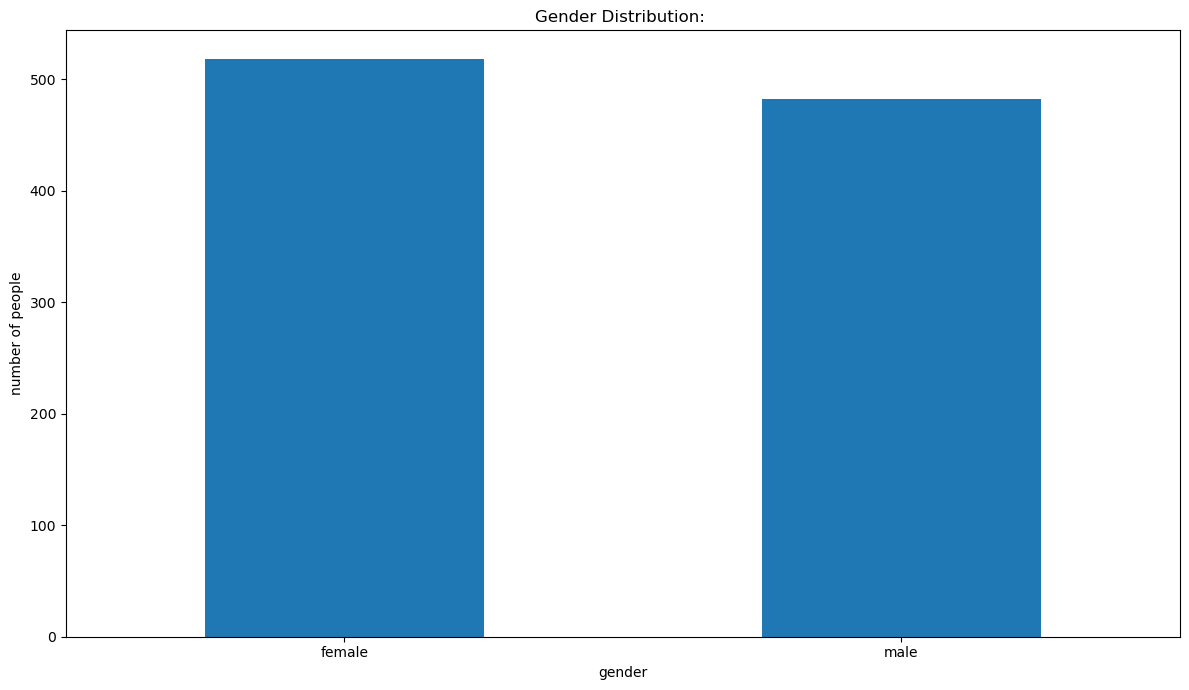


Race/ethnicity Distribution: 
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
----------------------------------------


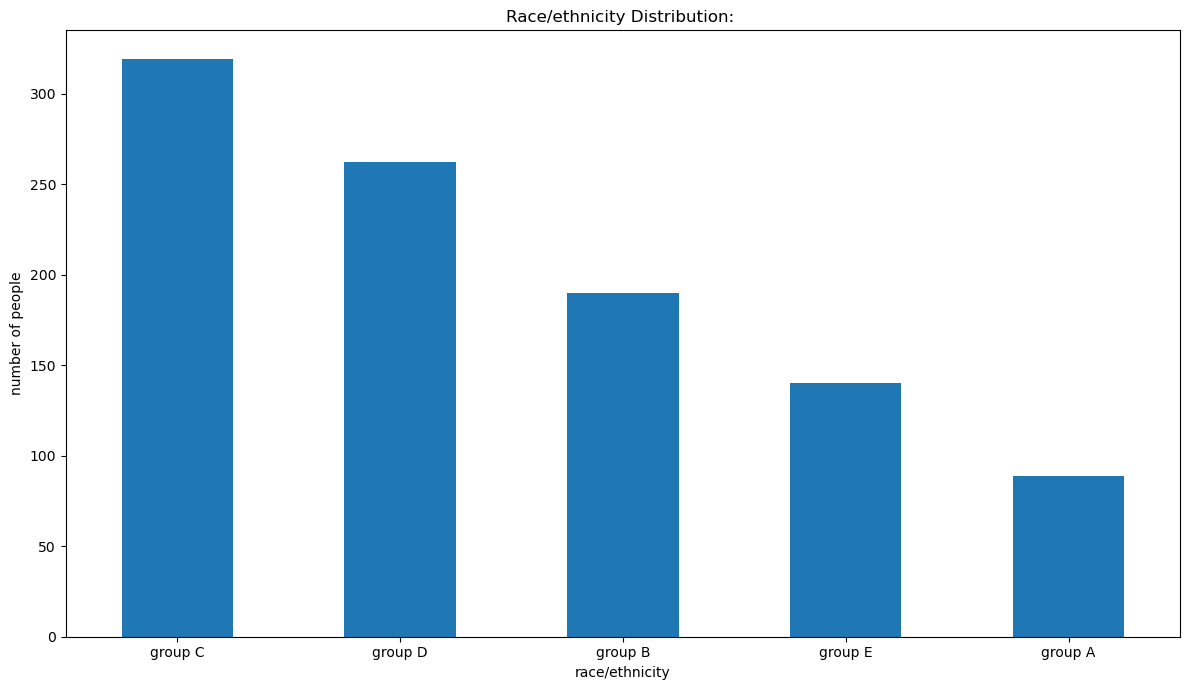


Parental_level_of_education Distribution: 
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
----------------------------------------


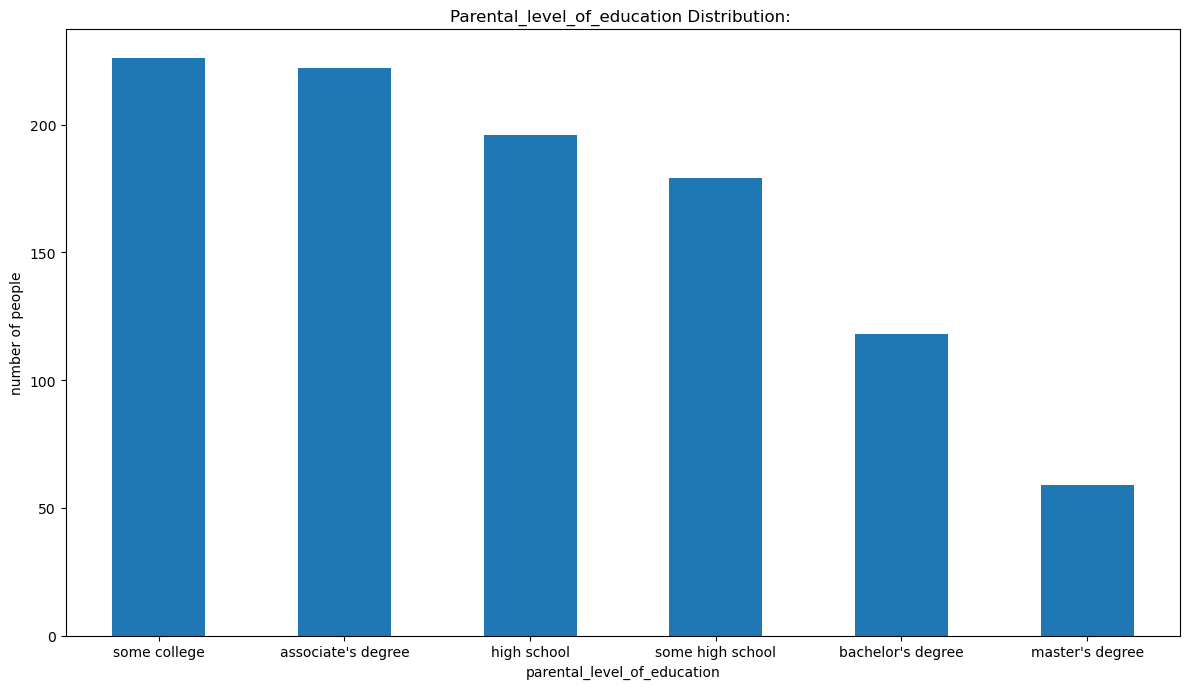


Lunch Distribution: 
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
----------------------------------------


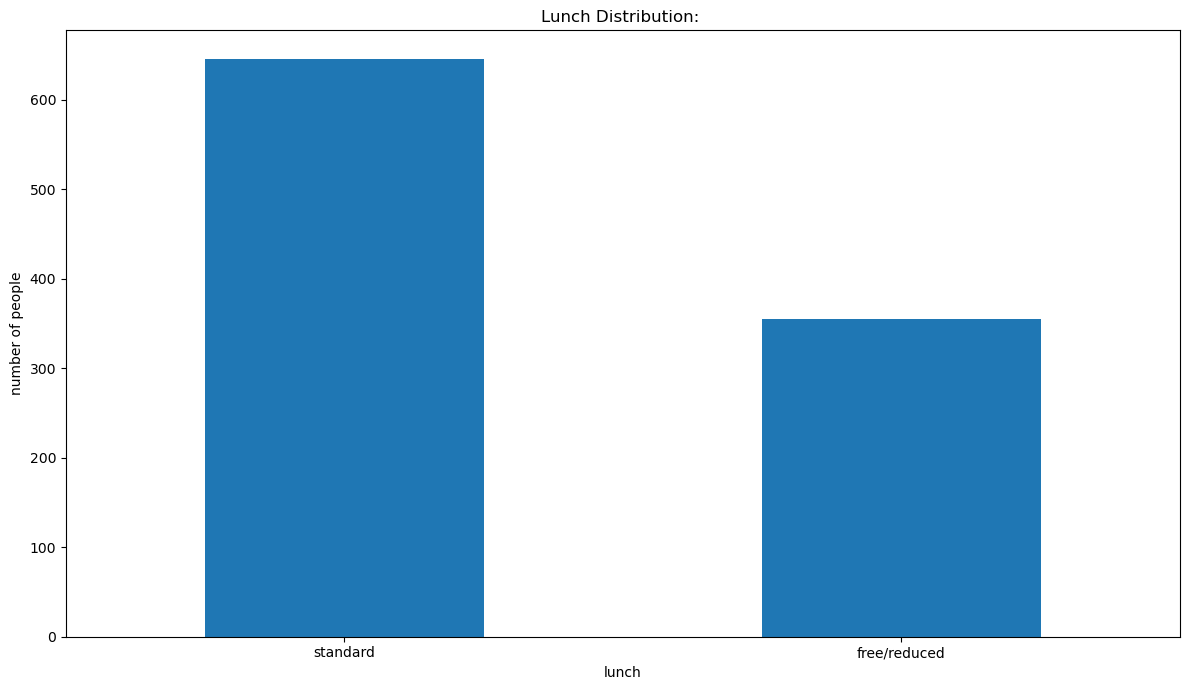


Test_preparation_course Distribution: 
test_preparation_course
none         642
completed    358
Name: count, dtype: int64
----------------------------------------


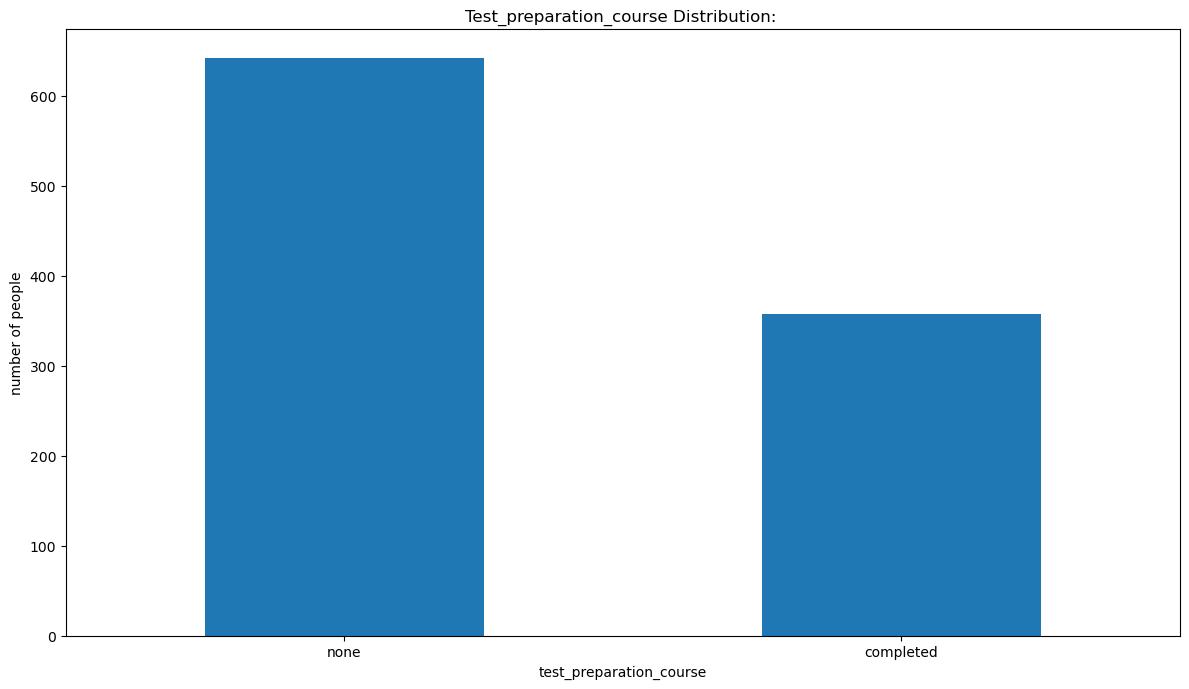

In [109]:
# create a disttribution for certain columns
cols_to_plot =['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']

for col in cols_to_plot:
    plt.figure(figsize=(12,7))
    col_dis = df[col].value_counts()

    # table 

    print(f'\n{col.capitalize()} Distribution: ')
    print(col_dis)
    print('-'*40)

    # plot
    
    col_dis.plot(kind='bar')
    plt.ylabel('number of people')
    plt.xticks(rotation=0)
    plt.title(f'{col.capitalize()} Distribution: ')
    plt.tight_layout()
    plt.show()
    

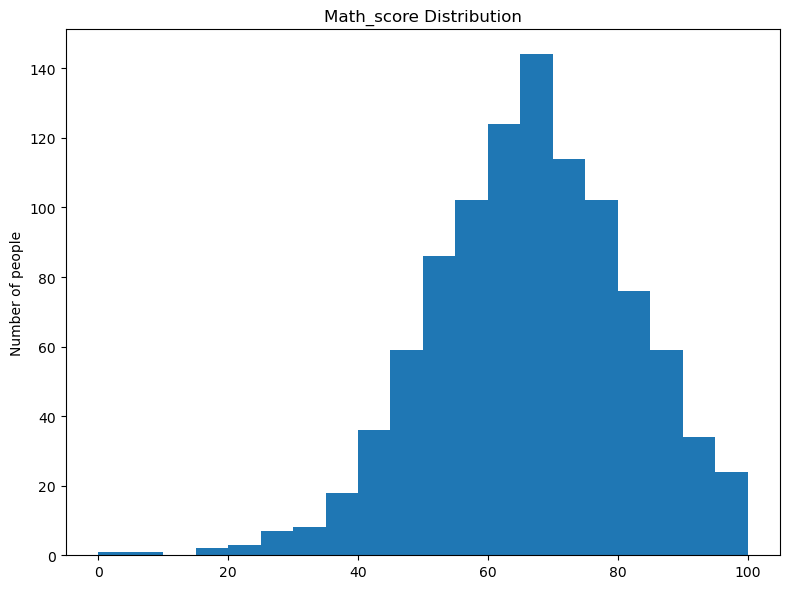

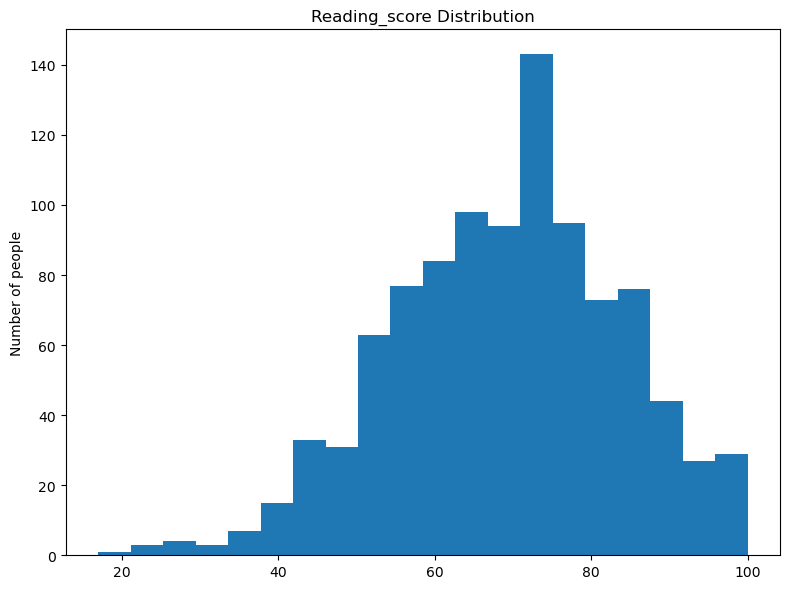

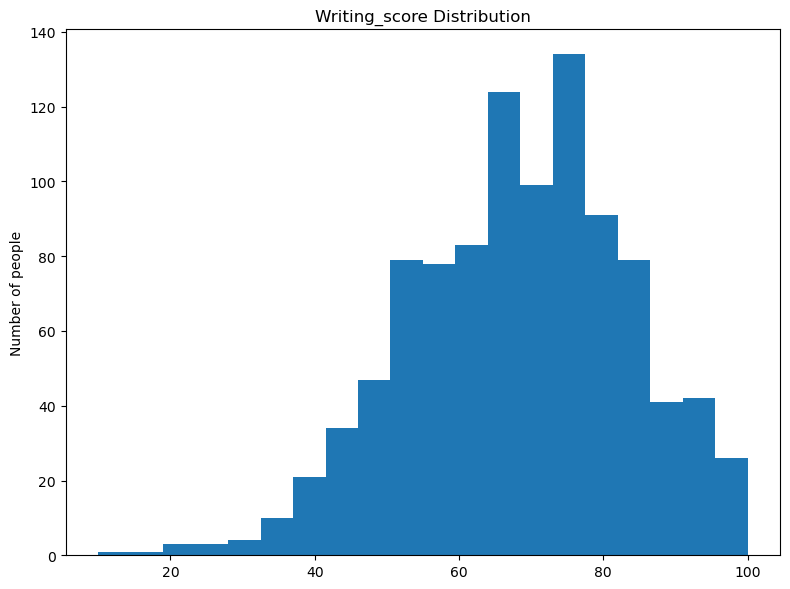

In [37]:
# check the distribution of the scores for the subjects
sub_consider = ['math_score', 'reading_score', 'writing_score']

# plot 
for sub in sub_consider:
    plt.figure(figsize=(8,6))
    plt.hist(df[sub], bins=20)
    plt.title(f'{sub.capitalize()} Distribution')
    plt.ylabel('Number of people')
    plt.tight_layout()
    plt.show()

## checking correlation between scores of various subjects

Correlation between math_score and writing_score : 0.803


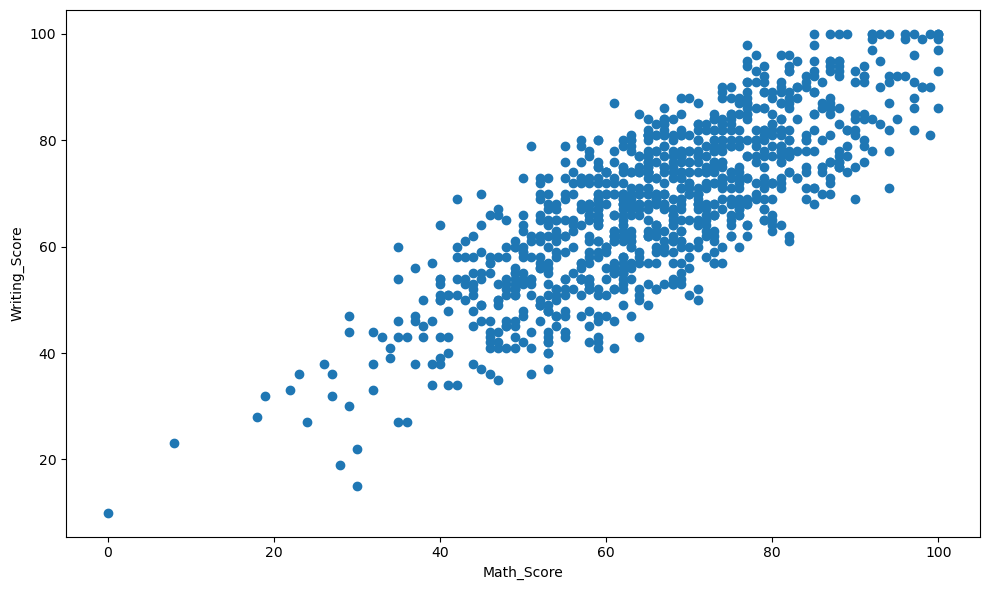

Correlation between math_score and reading_score : 0.818


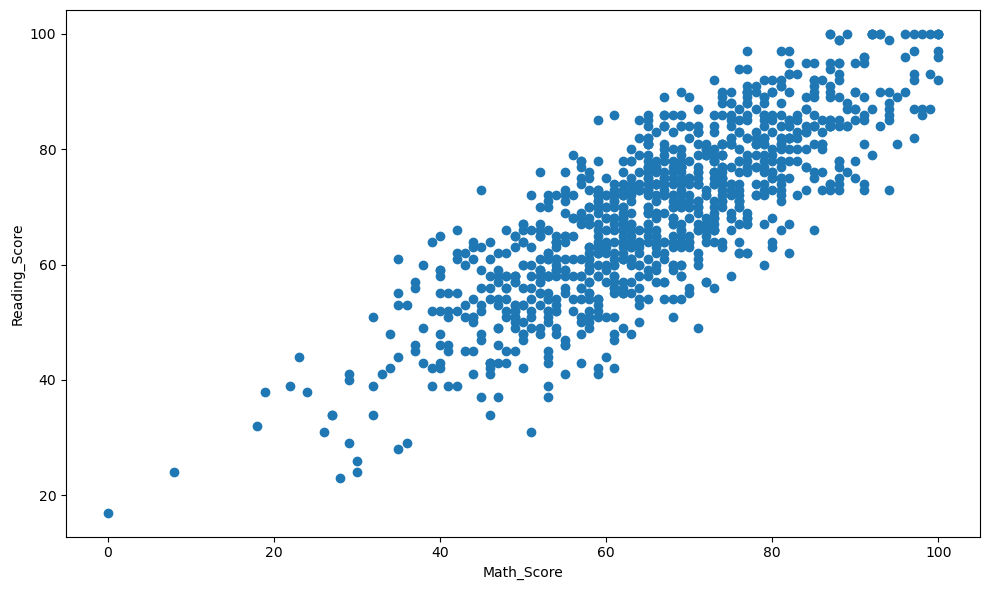

Correlation between writing_score and reading_score : 0.955


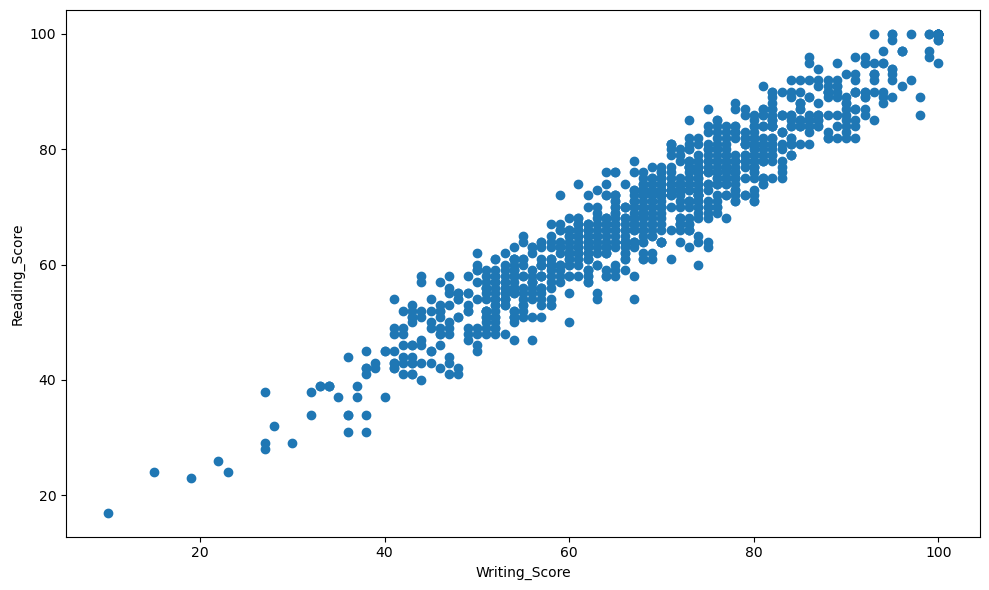

In [66]:
subjects = ['math_score', 'writing_score', 'reading_score']

for i in range(len(subjects)):
    for j in range(i+1, len(subjects)):
        corr = df[subjects[i]].corr(df[subjects[j]])
        print(f'Correlation between {subjects[i]} and {subjects[j]} : {corr:.3f}')

        #scatterplot
        plt.figure(figsize=(10,6))
        plt.scatter(df[subjects[i]], df[subjects[j]])
        plt.xlabel(subjects[i].title())
        plt.ylabel(subjects[j].title())
        plt.tight_layout()
        plt.show()

### checking the impact of hte categories on the scores of the various subjects

## Observations from the above data
###  Subject Correlations
- Strong positive correlation between subjects:
  - Math & Reading: **0.818**
  - Math & Writing: **0.803**
  - Reading & Writing: **0.955**
- This suggests students who excel in one subject tend to perform well across all subjects


 Math_Score by Gender
             mean        std  median  count
gender                                     
female  63.633205  15.491453    65.0    518
male    68.728216  14.356277    69.0    482
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

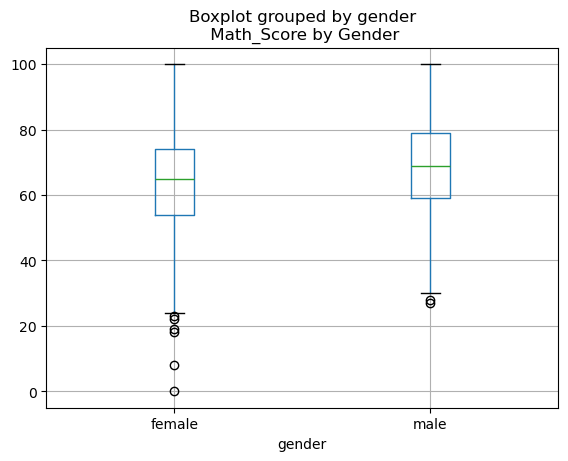


 Math_Score by Race/Ethnicity
                     mean        std  median  count
race/ethnicity                                     
group A         61.629213  14.523008    61.0     89
group B         63.452632  15.468191    63.0    190
group C         64.463950  14.852666    65.0    319
group D         67.362595  13.769386    69.0    262
group E         73.821429  15.534259    74.5    140
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

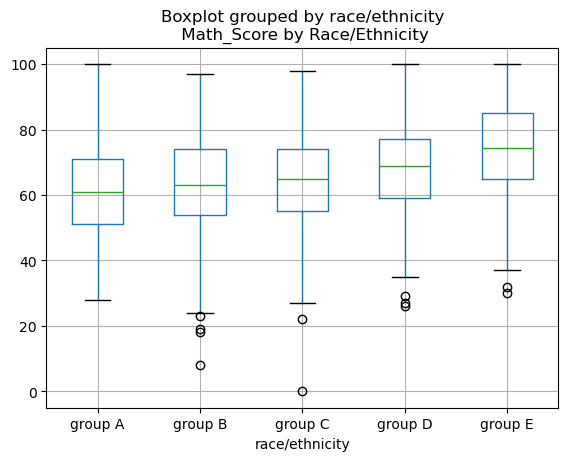


 Math_Score by Parental_Level_Of_Education
                                  mean        std  median  count
parental_level_of_education                                     
associate's degree           67.882883  15.112093    67.0    222
bachelor's degree            69.389831  14.943789    68.0    118
high school                  62.137755  14.539651    63.0    196
master's degree              69.745763  15.153915    73.0     59
some college                 67.128319  14.312897    67.5    226
some high school             63.497207  15.927989    65.0    179
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

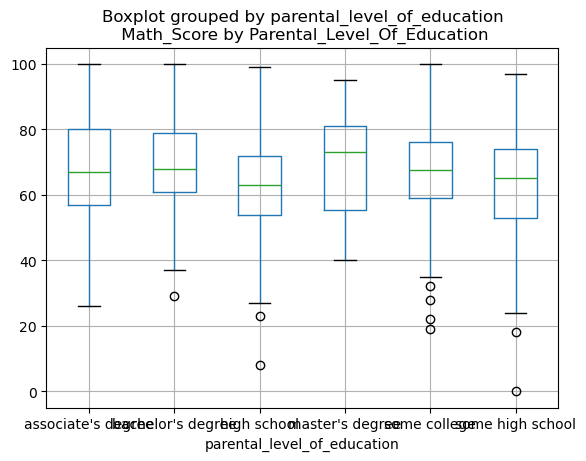


 Math_Score by Lunch
                   mean        std  median  count
lunch                                            
free/reduced  58.921127  15.159956    60.0    355
standard      70.034109  13.653501    69.0    645
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

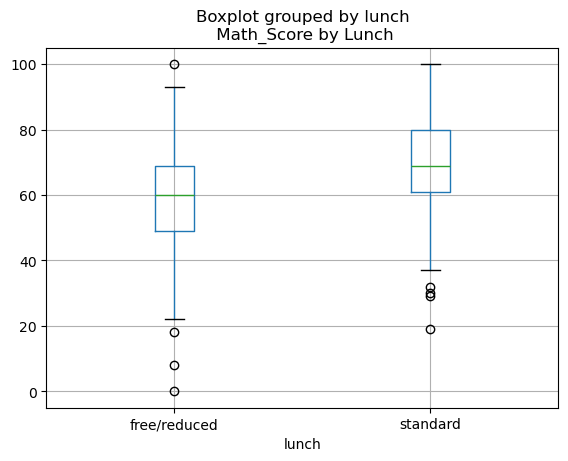


 Math_Score by Test_Preparation_Course
                              mean        std  median  count
test_preparation_course                                     
completed                69.695531  14.444699    69.0    358
none                     64.077882  15.192376    64.0    642
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

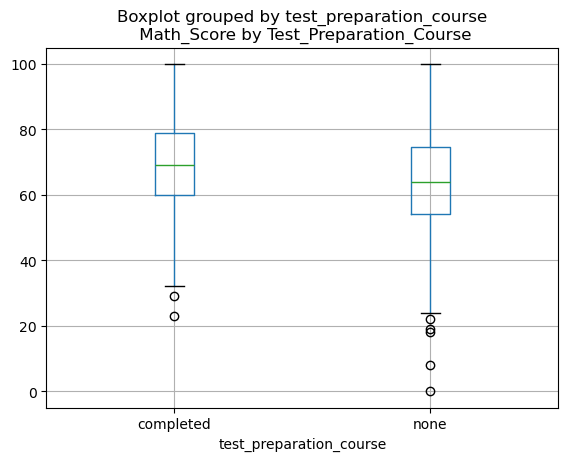


 Writing_Score by Gender
             mean        std  median  count
gender                                     
female  72.467181  14.844842    74.0    518
male    63.311203  14.113832    64.0    482
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

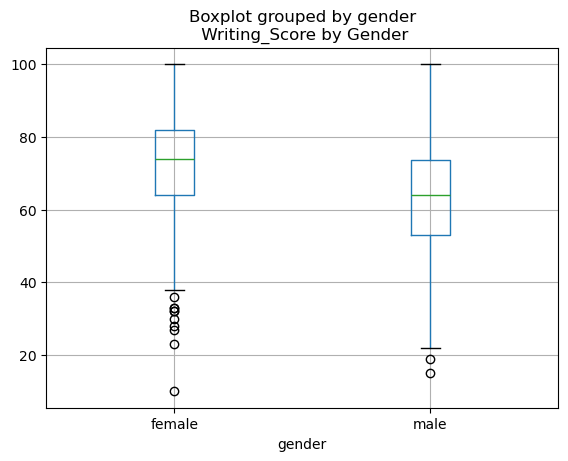


 Writing_Score by Race/Ethnicity
                     mean        std  median  count
race/ethnicity                                     
group A         62.674157  15.468278    62.0     89
group B         65.600000  15.625173    67.0    190
group C         67.827586  14.983378    68.0    319
group D         70.145038  14.367707    72.0    262
group E         71.407143  15.113906    72.0    140
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

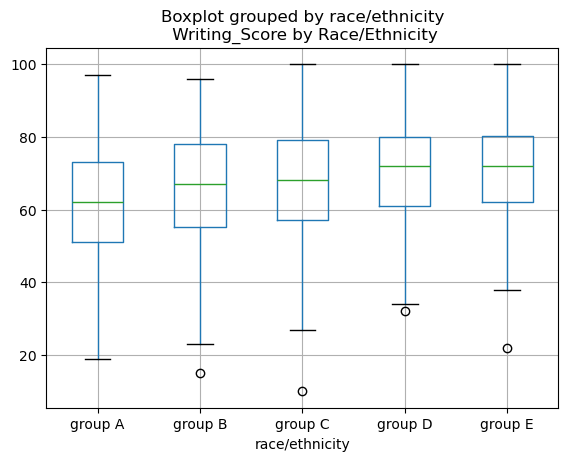


 Writing_Score by Parental_Level_Of_Education
                                  mean        std  median  count
parental_level_of_education                                     
associate's degree           69.896396  14.311122    70.5    222
bachelor's degree            73.381356  14.728262    74.0    118
high school                  62.448980  14.085907    64.0    196
master's degree              75.677966  13.730711    75.0     59
some college                 68.840708  15.012331    70.0    226
some high school             64.888268  15.736197    66.0    179
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

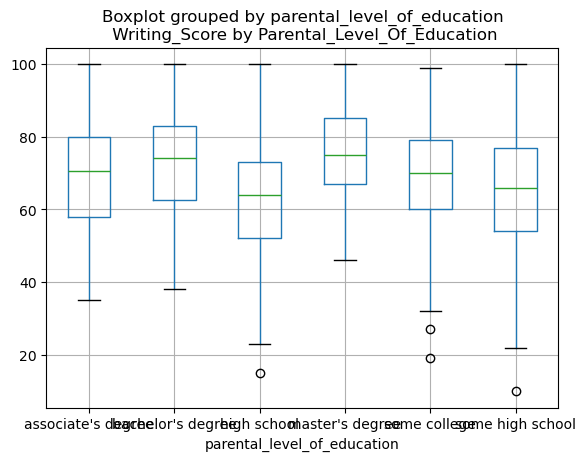


 Writing_Score by Lunch
                   mean        std  median  count
lunch                                            
free/reduced  63.022535  15.433823    64.0    355
standard      70.823256  14.339487    72.0    645
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

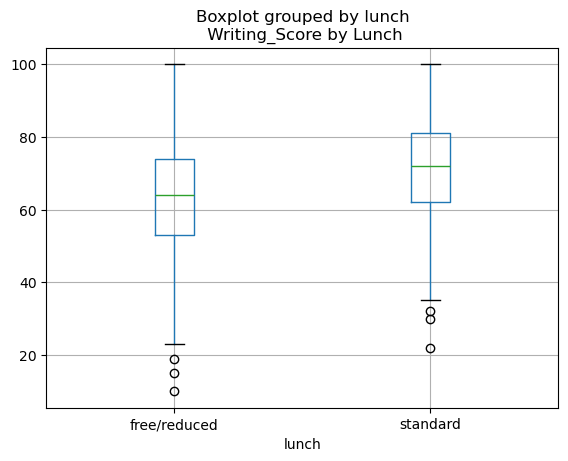


 Writing_Score by Test_Preparation_Course
                              mean        std  median  count
test_preparation_course                                     
completed                74.418994  13.375335    76.0    358
none                     64.504673  14.999661    65.0    642
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

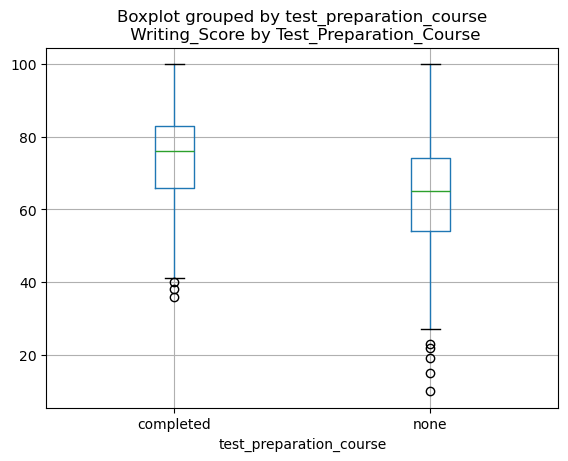


 Reading_Score by Gender
             mean        std  median  count
gender                                     
female  72.608108  14.378245    73.0    518
male    65.473029  13.931832    66.0    482
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

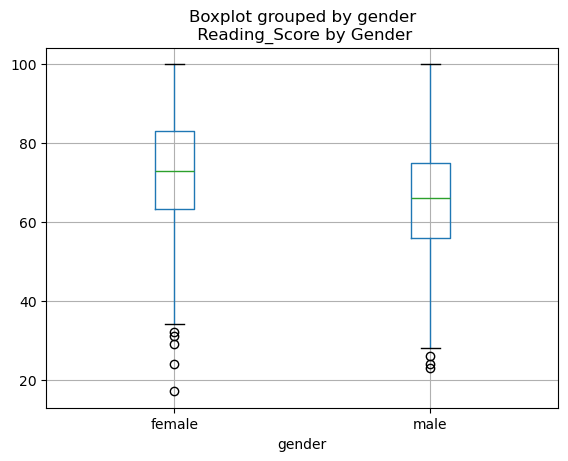


 Reading_Score by Race/Ethnicity
                     mean        std  median  count
race/ethnicity                                     
group A         64.674157  15.543762    64.0     89
group B         67.352632  15.177499    67.0    190
group C         69.103448  13.997033    71.0    319
group D         70.030534  13.895306    71.0    262
group E         73.028571  14.874024    74.0    140
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

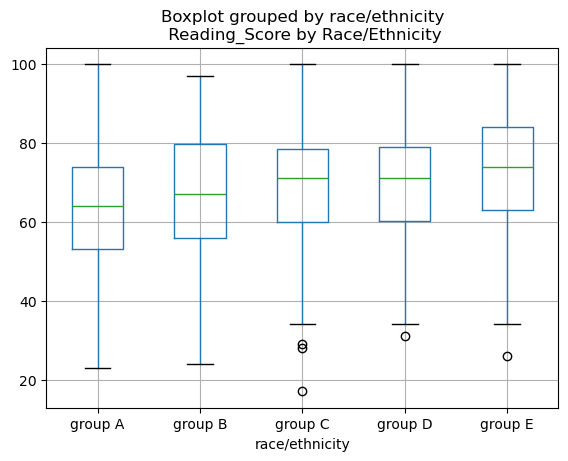


 Reading_Score by Parental_Level_Of_Education
                                  mean        std  median  count
parental_level_of_education                                     
associate's degree           70.927928  13.868948    72.5    222
bachelor's degree            73.000000  14.285250    73.0    118
high school                  64.704082  14.132130    66.0    196
master's degree              75.372881  13.775163    76.0     59
some college                 69.460177  14.057049    70.5    226
some high school             66.938547  15.479295    67.0    179
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

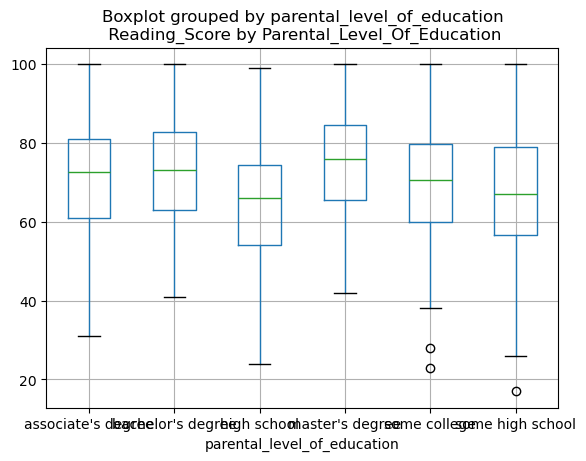


 Reading_Score by Lunch
                   mean        std  median  count
lunch                                            
free/reduced  64.653521  14.895339    65.0    355
standard      71.654264  13.830602    72.0    645
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

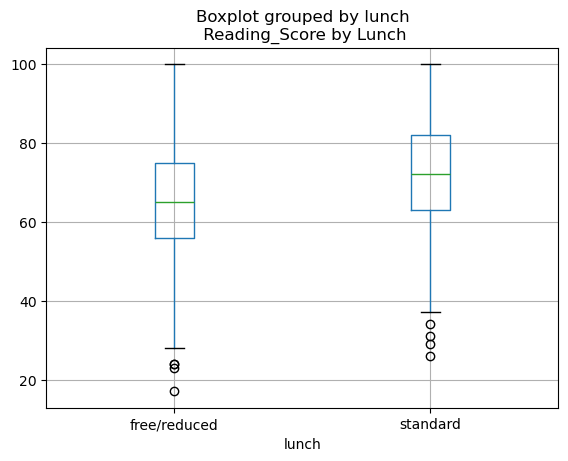


 Reading_Score by Test_Preparation_Course
                              mean        std  median  count
test_preparation_course                                     
completed                73.893855  13.638384    75.0    358
none                     66.534268  14.463885    67.0    642
--------------------------------------------------------------------------------


<Figure size 1100x700 with 0 Axes>

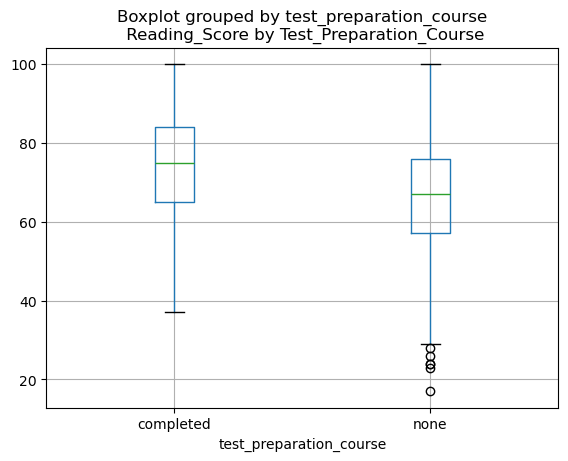

In [121]:
subjects = ['math_score', 'writing_score', 'reading_score']
category =['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']

for sub in subjects:
    #summary statistics
    for cat in category:
        print(f'\n {sub.title()} by {cat.title()}')
        print(df.groupby(cat)[sub].agg(['mean', 'std', 'median', 'count']))
        print('--'*40)

        #boxplots
        plt.figure(figsize=(11,7))
        df.boxplot(column = sub, by=cat)
        plt.title(f'\n {sub.title()} by {cat.title()}')
        plt.show()

# Observations from the above box plots
### 1. Socioeconomic Factors
- **Lunch Type**: Students with standard lunch outperformed those with free/reduced lunch by **8** points
- **Parental Education**: Students whose parents held bachelor's degrees or higher scored **11** points higher than those whose parents had high school education
### 2. Gender Differences
- Females outperformed males in Reading by **7** points and Writing by **9** points
- Males showed slightly higher performance in Math by **5** points

### 3. Race/Ethnicity Patterns
- **Group E** showed highest average scores (73 points)
- Score gap between highest and lowest performing groups: **12** points
- 
### 4. Test Preparation Impact
- Students who completed test preparation scored **7** points higher on average
- Impact was consistent across all subjects (Math: **5** pts, Reading: **7** pts, Writing: **10** pts)

In [89]:
# Add total/average score column
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3

# Analyze factors with total performance
print("\n" + "="*60)
print("FACTORS AFFECTING OVERALL PERFORMANCE")
print("="*60)

for cat in category:
    print(f"\n{cat.replace('_', ' ').title()}:")
    avg_by_group = df.groupby(cat)['average_score'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(avg_by_group)


FACTORS AFFECTING OVERALL PERFORMANCE

Gender:
             mean  count
gender                  
female  69.569498    518
male    65.837483    482

Race/Ethnicity:
                     mean  count
race/ethnicity                  
group E         72.752381    140
group D         69.179389    262
group C         67.131661    319
group B         65.468421    190
group A         62.992509     89

Parental Level Of Education:
                                  mean  count
parental_level_of_education                  
master's degree              73.598870     59
bachelor's degree            71.923729    118
associate's degree           69.569069    222
some college                 68.476401    226
some high school             65.108007    179
high school                  63.096939    196

Lunch:
                   mean  count
lunch                         
standard      70.837209    645
free/reduced  62.199061    355

Test Preparation Course:
                              mean  count
test_p

## 💡 Recommendations

Based on the analysis, here are actionable recommendations for improving student performance:

1. **Expand Test Preparation Programs**
   - Test prep shows the strongest controllable impact on scores
   - Prioritize access for economically disadvantaged students

2. **Parental Engagement Initiatives**
   - Create programs to help parents support their children's education
   - Focus on families where parents have lower educational attainment

3. **Address Socioeconomic Disparities**
   - Students from lower-income backgrounds (free/reduced lunch) need additional support
   - Consider tutoring programs, mentorship, or after-school resources

4. **Targeted Subject Support**
   - Given strong correlations between subjects, improving foundational skills benefits all areas
   - Focus on reading comprehension as it correlates strongly with all subjects

5. **Gender-Specific Interventions**
   - Encourage male students in reading and writing through engaging content
   - Promote female participation in advanced math programs

---

## Conclusion

This comprehensive analysis of 1,000 student performance records has revealed significant insights into the factors that influence academic achievement across Mathematics, Reading, and Writing.

### Key Takeaways

**1. Strong Inter-Subject Correlations**
The analysis revealed strong positive correlations between all three subjects, indicating that students who perform well in one area tend to excel across the board. This suggests that foundational skills and general academic preparedness have broad impacts on student success.

**2. Impact of Controllable Factors**
Test preparation and parental involvement (proxied by education level) emerged as significant factors affecting student performance. These represent actionable areas where schools can intervene to improve outcomes.

**3. Socioeconomic Disparities**
Clear performance gaps exist between students from different socioeconomic backgrounds, as indicated by lunch program participation. Students with access to standard lunch programs consistently outperformed those on free/reduced lunch programs, highlighting the need for targeted support for economically disadvantaged students.

**4. Demographic Patterns**
Gender and race/ethnicity showed varying impacts across different subjects, with some groups demonstrating strengths in specific areas. Understanding these patterns can help educators tailor their teaching approaches to better serve diverse student populations.

**5. Parental Education Influence**
The level of parental education showed a clear correlation with student performance, suggesting that family educational background plays a crucial role in providing academic support and resources at home.

### Implications for Educational Practice

Based on these findings, several actionable strategies emerge:

- **Expand Test Preparation Access**: Prioritize test preparation programs, especially for students from lower-income backgrounds who show the greatest potential for improvement
- **Early Intervention Programs**: Identify at-risk students early based on demographic and socioeconomic factors to provide timely support
- **Family Engagement Initiatives**: Develop programs to help parents support their children's education, particularly targeting families where parents have lower educational attainment
- **Resource Allocation**: Direct additional resources and support staff to schools serving higher proportions of economically disadvantaged students
- **Holistic Support**: Given the strong correlations between subjects, focus on building foundational skills that benefit performance across all academic areas

### Limitations

This analysis has several limitations that should be considered:

- **Sample Representation**: The dataset of 1,000 students may not be representative of all schools or districts
- **Causation vs. Correlation**: While we identified relationships between factors and performance, we cannot definitively establish causation from this observational data
- **Missing Variables**: Important factors such as teacher quality, class size, school resources, student motivation, and study habits are not captured in this dataset
- **Temporal Factors**: This cross-sectional analysis provides a snapshot in time but doesn't capture changes in performance over time or the long-term effects of interventions
- **Contextual Information**: The dataset lacks information about specific school contexts, geographic location, or other environmental factors that may influence performance

### Future Work

To build upon this analysis, future research could:

1. **Predictive Modeling**: Develop machine learning models to predict student performance and identify at-risk students before they fall behind
2. **Longitudinal Analysis**: Track student performance over time to understand how factors influence growth and improvement
3. **Intervention Studies**: Conduct controlled experiments to test the effectiveness of specific interventions suggested by this analysis
4. **Deeper Statistical Testing**: Apply hypothesis testing and ANOVA to validate the statistical significance of observed differences
5. **Interaction Effects**: Investigate how multiple factors combine and interact to influence student outcomes
6. **Expanded Dataset**: Incorporate additional variables such as attendance, behavior records, extracurricular participation, and school resources
7. **Qualitative Research**: Complement quantitative findings with interviews and surveys to understand the lived experiences behind the data

### Final Thoughts

Education is a complex, multifaceted endeavor, and data analysis provides just one lens through which to understand and improve student outcomes. While the patterns identified in this analysis are informative, they represent starting points for deeper investigation rather than definitive answers.

The ultimate goal of this analysis is to contribute to more equitable and effective educational practices. By understanding which factors most strongly influence student success, educators and policymakers can make more informed decisions about where to invest resources and how to design interventions that give every student the opportunity to reach their full potential.

Data-driven insights, combined with the expertise of educators and the voices of students and families, can help create learning environments where all students thrive, regardless of their background or circumstances.

---

**Analysis completed on:** [Current Date]

**Tools used:** Python 3.x, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

**Dataset:** 1,000 student performance records across 8 variables

---